# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
weather_nom = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

In [4]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4



---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [5]:
df['month_year'] = df.index.to_period('M')
df['month_year'] = df['month_year'].astype(str)

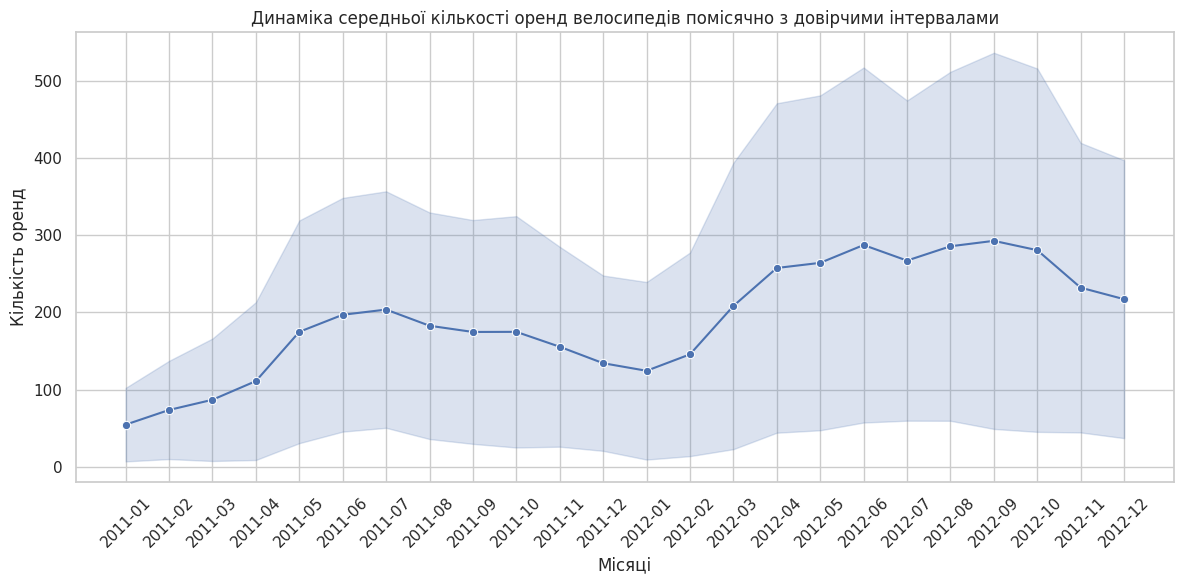

In [6]:
plt.figure(figsize=(12, 6))

sns.lineplot(df, x='month_year', y='count', errorbar='sd', marker='o')
plt.title('Динаміка середньої кількості оренд велосипедів помісячно з довірчими інтервалами')
plt.xlabel('Місяці')
plt.ylabel('Кількість оренд')
plt.xticks(rotation=45)
plt.tight_layout();

Найбільша невизначеність спостерігається на графіку там, де найширша область напівпрозорої області, оскільки она показує стандартне відхилення від середнього значення. Це місяці: червень 2012 року (2012-06), серпень, вересень та жовтень 2012 року (2012-08, 2012-09, 2012-10).

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

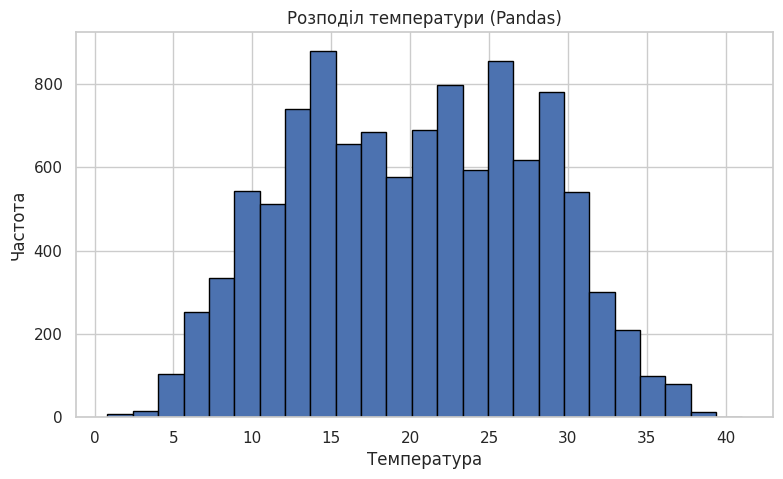

In [7]:
df['temp'].plot.hist(bins=25, edgecolor='black',
                     figsize=(9, 5),
                     title='Розподіл температури (Pandas)',
                     xlabel='Температура',
                     ylabel='Частота');

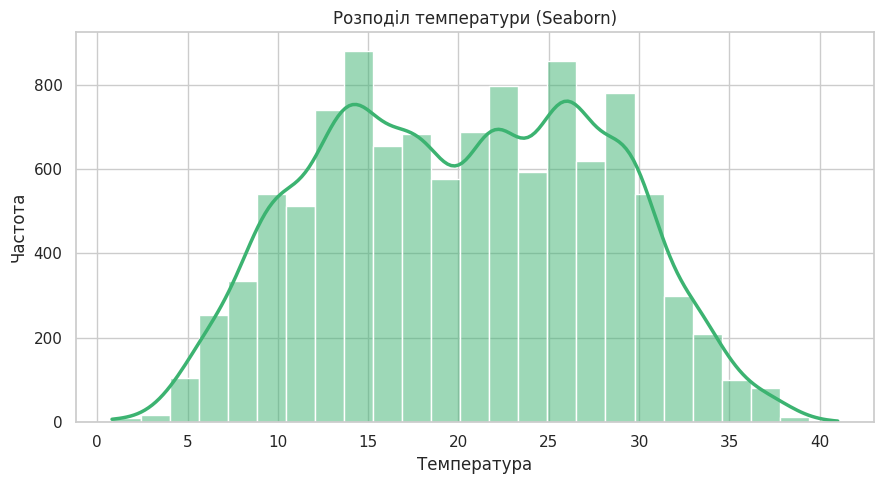

In [8]:
plt.figure(figsize=(9, 5))

sns.histplot(df, x='temp', bins=25,
             color='mediumseagreen',                                              # Задає колір для стовпчиків
             kde=True, line_kws={'color': 'darkred','linewidth': 2.5})            # Колір та товщина лінії KDE
plt.title('Розподіл температури (Seaborn)')
plt.xlabel('Температура')
plt.ylabel('Частота')
plt.tight_layout();

Pandas будує гістограму з чіткими стовпчиками.

Seaborn надає більш естетичне згладжування. Сам графік ширший, хоча я задавала однаковий розмір для обох графіків.

Параметр kde=True додатково накладає лінію оцінки щільності розподілу (Kernel Density Estimate), яка плавно показує формацію піків температури.

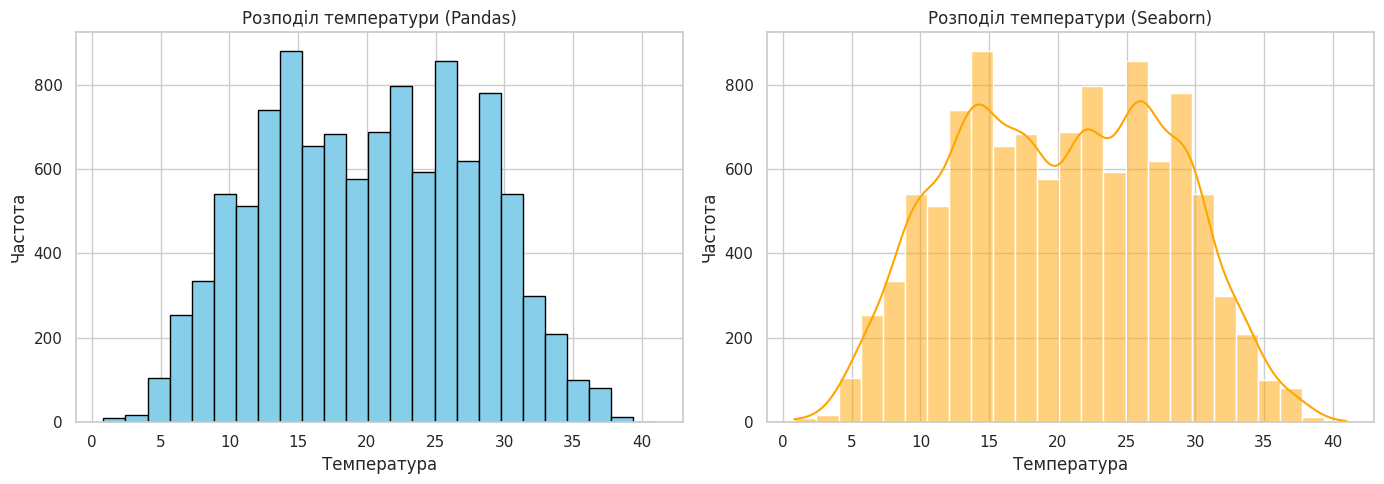

In [9]:
# Створюємо полотно для 2 графіків поруч
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Гістограма Pandas
df['temp'].plot.hist(bins=25, ax=ax[0], color='skyblue', edgecolor='black')
ax[0].set_title('Розподіл температури (Pandas)')
ax[0].set_xlabel('Температура')
ax[0].set_ylabel('Частота')

# 2. Гістограма Seaborn (з kde=True)
sns.histplot(data=df, x='temp', bins=25, kde=True, ax=ax[1], color='orange')
ax[1].set_title('Розподіл температури (Seaborn)')
ax[1].set_xlabel('Температура')
ax[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

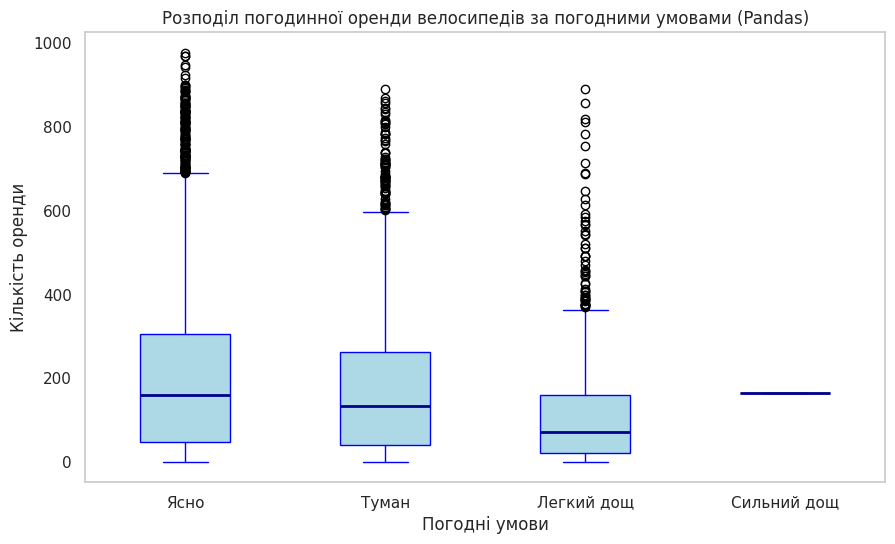

In [10]:
weather_nom = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']

df.boxplot(
    column='count',
    by='weather',
    figsize=(10, 6),
    grid = False,
    patch_artist=True,                                   # Дозволяє зафарбовувати внутрішню частину ящиків
    boxprops=dict(facecolor='lightblue', color='blue'),  # facecolor — заливка, color — контур
    medianprops=dict(color='darkblue', linewidth=2),     # Колір та товщина лінії медіани
    whiskerprops=dict(color='blue'),                     # Колір "вусів"
    capprops=dict(color='blue')                          # Колір кінцевих засічок
)
plt.title('Розподіл погодинної оренди велосипедів за погодними умовами (Pandas)')
plt.suptitle('')
plt.ylabel('Кількість оренди')
plt.xlabel('Погодні умови')

plt.xticks([1, 2, 3, 4], weather_nom)                 # Замінюємо числові мітки 1, 2, 3, 4 на текстові назви погоди
plt.show()


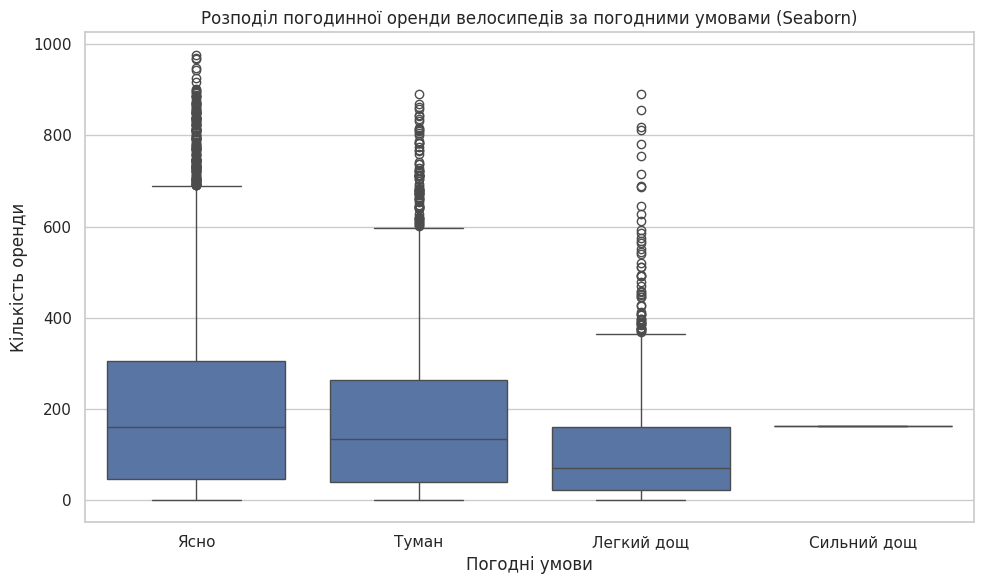

In [11]:
weather_nom = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']

plt.figure(figsize=(10, 6))

sns.boxplot(df, x='weather', y='count')
plt.title('Розподіл погодинної оренди велосипедів за погодними умовами (Seaborn)')
plt.ylabel('Кількість оренди')
plt.xlabel('Погодні умови')
plt.xticks([0, 1, 2, 3], weather_nom)
plt.tight_layout();

Візуальна різниця між Pandas та Seaborn бокс-плотами:
при однаковому заданому розмірі графік з Seaborn ширший. Також форма боксів відрізняється. Для того, щоб зафарбувати бокви в Pandas потрібно писати додатковий код, інакше бокси будуть прозорі.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


In [12]:
correlation = df[['temp', 'atemp',	'humidity', 'windspeed', 'count']].corr()

In [13]:
correlation

,temp,atemp,humidity,windspeed,count
temp,1.000000,0.984948,-0.064949,-0.017852,0.394454
atemp,0.984948,1.000000,-0.043536,-0.057473,0.389784
humidity,-0.064949,-0.043536,1.000000,-0.318607,-0.317371
windspeed,-0.017852,-0.057473,-0.318607,1.000000,0.101369
count,0.394454,0.389784,-0.317371,0.101369,1.000000


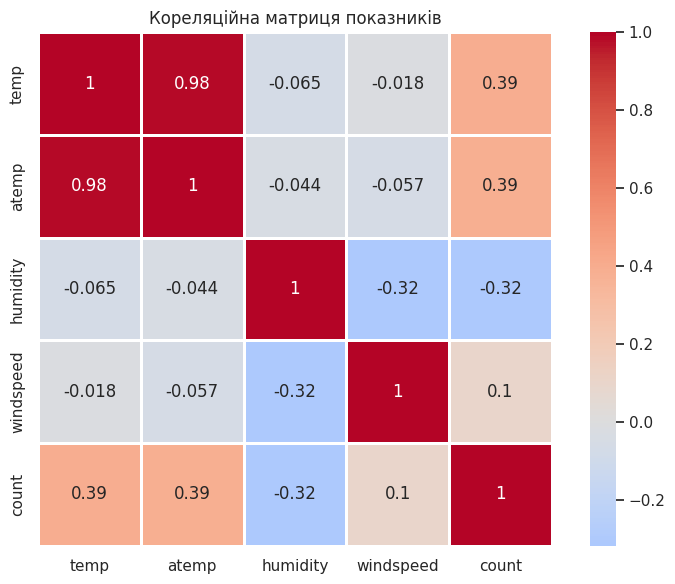

In [14]:
plt.figure(figsize=(8, 6))

sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1)
plt.title('Кореляційна матриця показників')
plt.tight_layout()
plt.show()

Питання по графіку:

1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?

temp (фактична температура) та atemp (відчувана температура) мають найсильніший позитивний зв'язок із кількістю оренд (коефіцієнт кореляції 0.39). Зі зростанням температури кількість оренд має чітку тенденцію до збільшення.
Негативний зв'язок із count має humidity (вологість) — коефіцієнт -0.32.

2. Яка кореляція між temp та atemp? Чому?

Кореляція між temp та atemp становить 0.98. Це відбувається тому, що відчувану температуру встановлюють на підстаі реальної, але з урахуванням інших показників. Тому вони майже ідентичні.

3. Які змінні мають негативну кореляцію?
На тепловій карті вони зафарбовані сірим та блакитним кольором.

humidity та count (-0.32) — висока вологість знижує кількість оренд.

humidity та windspeed (-0.32) — зі зростанням вологості швидкість вітру в даних нижча.

humidity та temp (-0.065) і humidity та atemp (-0.044) — слабка негативна залежність.

windspeed та temp (-0.018) і windspeed та atemp (-0.057) — слабка негативна залежність.


## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


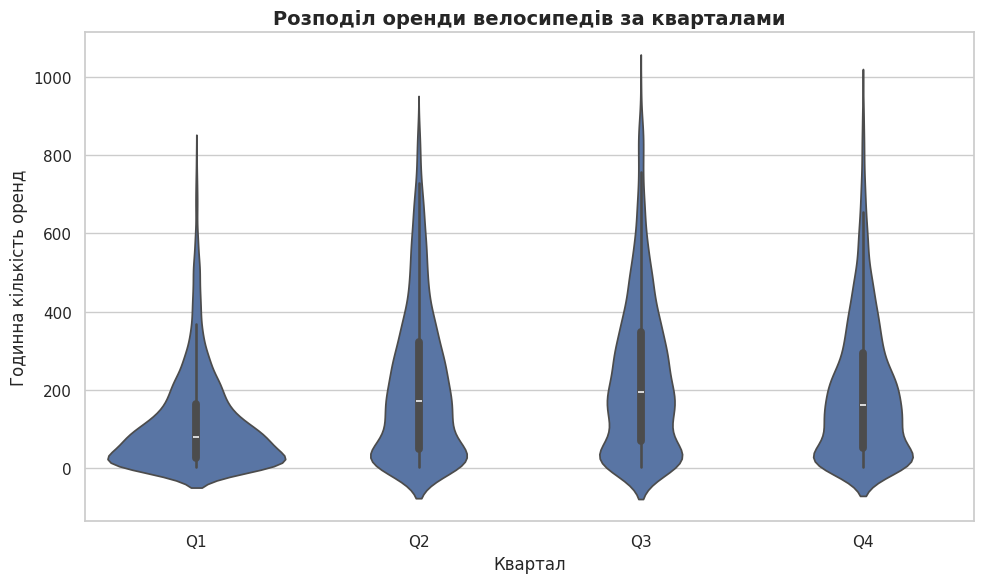

In [15]:
# 1. Створюємо колонку з номером кварталу (1, 2, 3, 4)
df['quarter'] = df.index.quarter

# 2. Побудова violin plot
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x='quarter',
    y='count',
    )

plt.title('Розподіл оренди велосипедів за кварталами', fontsize=14, fontweight='bold')
plt.xlabel('Квартал')
plt.ylabel('Годинна кількість оренд')

# Замінюємо цифри 0, 1, 2, 3 на назви кварталів
plt.xticks(ticks=[0, 1, 2, 3], labels=['Q1', 'Q2', 'Q3', 'Q4'])

plt.tight_layout()
plt.show()

Питання для інтерпретації:

1. Що показує "товщина" violin plot?

Вона показує щільність розподілу. Чим ширший графік на певній висоті, тим частіше зустрічається саме така кількість оренд.

2. В якому кварталі найбільша варіабельність оренди?

Найбільша варіабельність спостерігається у кварталі Q3. Він є самим витягнутим по вертикалі.

3. Яка перевага violin plot над звичайним box plot?

Box plot виглядає як симетричний прямокутник і не дає уявлення про те, де саме сконцентрована більшість спостережень. Violin plot через ширину контуру одразу візуалізує реальну графічну форму розподілу даних.


## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

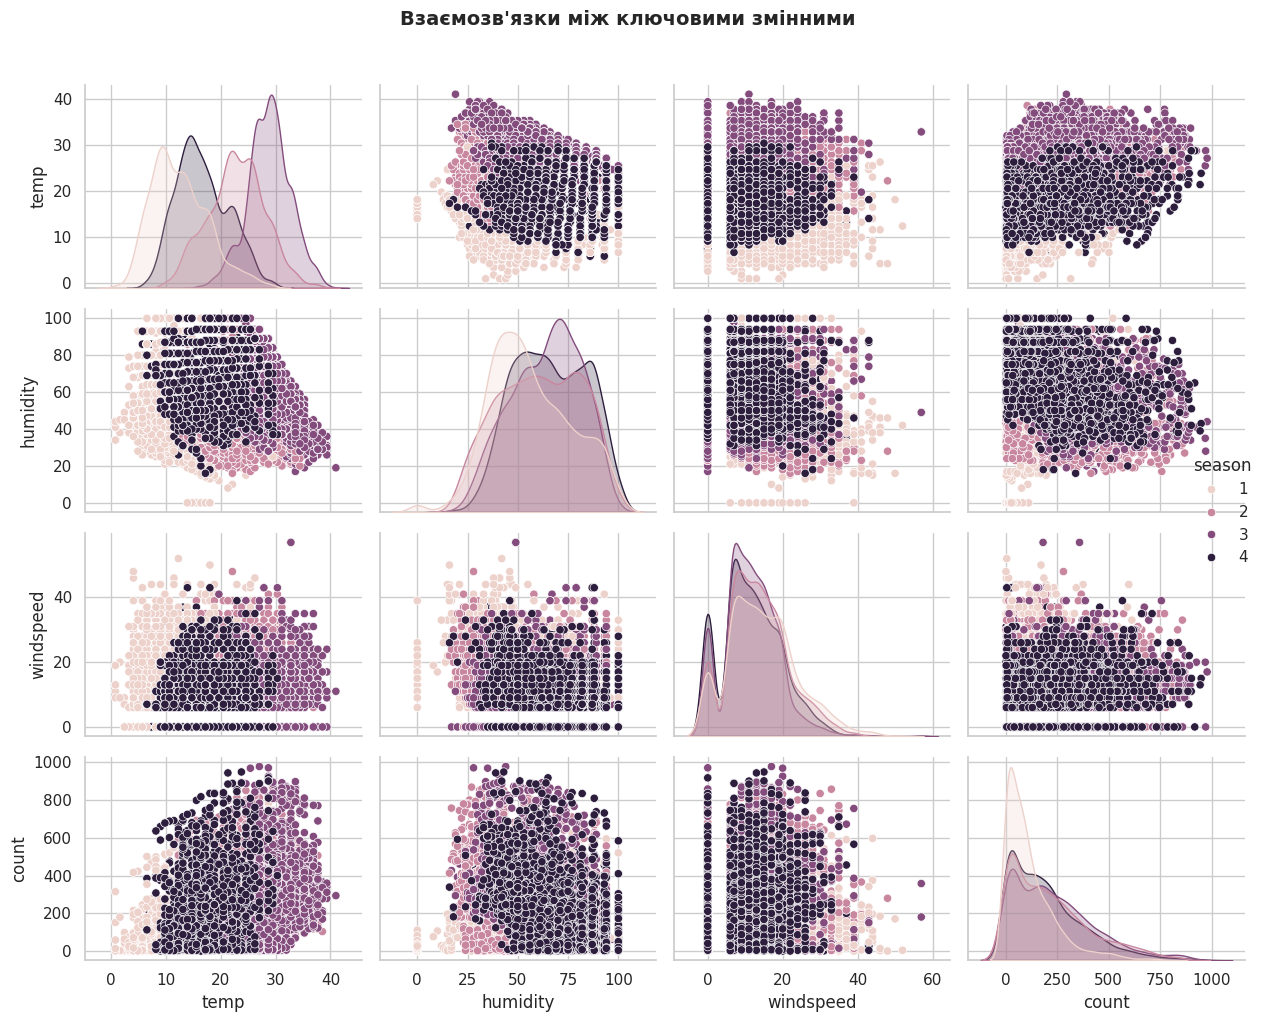

In [16]:
sample_df = df[['temp', 'humidity', 'windspeed', 'count', 'season']]

sns.pairplot(sample_df, height=2.5, aspect=1.2, hue='season')
plt.suptitle('Взаємозв\'язки між ключовими змінними', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show();

Питання для інтерпретації:


1. Між якими змінними спостерігається найсильніший лінійний зв'язок?

temp (температура) та count (кількість оренд): на графіку розсіювання (перетин temp та count) чітко видно — зі зростанням температури максимальні та середні показники оренди систематично збільшуються.

2. Яка характеристика найбільше відрізняється між кварталами?

temp (температура): це видно на діагональному графіку у лівому верхньому кутку.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

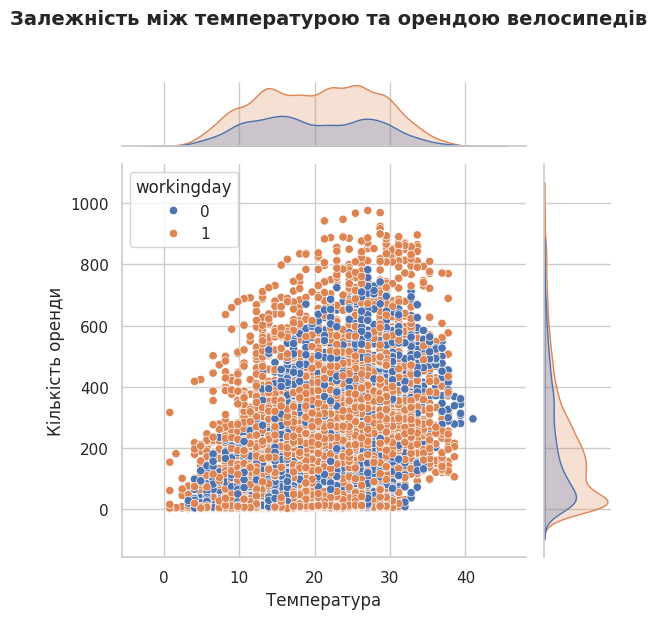

In [28]:
sns.jointplot(data=df, x='temp', y='count', hue='workingday')

plt.suptitle('Залежність між температурою та орендою велосипедів', fontsize=14, fontweight='bold', y=1.03)           # y=1.03 — розміщує заголовок над верхньою діаграмою щільності, прибираючи перекриття
plt.xlabel('Температура')
plt.ylabel('Кількість оренди')
plt.tight_layout()
plt.show();

Питання для інтерпретації:

1. Що показують графіки по краях?

Верхній графік: показує щільність розподілу температури (temp) окремо для робочих та вихідних днів.

Правий графік: показує щільність розподілу кількості оренд (count) для кожного типу дня.

2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

У робочі дні (помаранчеві точки) частіше зустрічаються максимально високі показники оренди, що пояснюється використанням велосипедів для поїздок на роботу чи навчання у години пік.

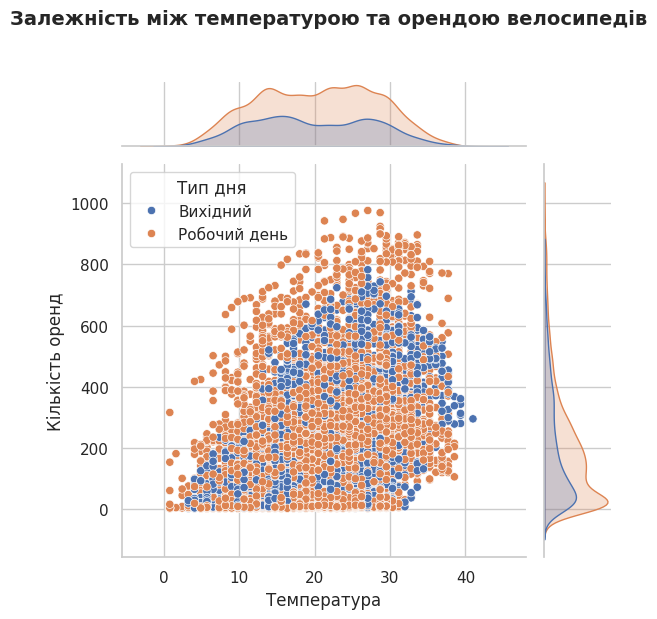

In [29]:
g = sns.jointplot(data=df, x='temp', y='count', hue='workingday')

plt.suptitle('Залежність між температурою та орендою велосипедів', fontsize=14, fontweight='bold', y=1.03)
plt.xlabel('Температура')
plt.ylabel('Кількість оренд')

# Зберігаємо оригінальні кольорові маркери (handles) та міняємо тільки текст
ax = g.ax_joint
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=['Вихідний', 'Робочий день'], title='Тип дня')

plt.tight_layout()
plt.show();